<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/SQL_1_Chinook_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL - Chinook


## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [ ]:
# Install the sqlite package for Ubuntu
# Download the Chinook sqlite database
# import sqlite3 as db
# import pandas as pd

In [ ]:
import sqlite3 as db
import pandas as pd
from google.colab import output as web_output

In [ ]:
%%capture install_output
%%bash
apt-get update
apt-get install -y sqlite3
pip install sqlite-web


In [ ]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip

Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [ ]:
!rm -f chinook.db #to remove any previous downloads of chinook.

In [ ]:
!unzip -u chinook.zip

Archive:  chinook.zip
  inflating: chinook.db              


In [ ]:
!ls -la #to list the files in the directory

total 1180
drwxr-xr-x 1 root root   4096 May  5 23:02 .
drwxr-xr-x 1 root root   4096 May  5 21:54 ..
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
-rw-r--r-- 1 root root 305596 May  5 23:02 chinook.zip
drwxr-xr-x 4 root root   4096 Apr 16 13:28 .config
drwxr-xr-x 1 root root   4096 Apr 16 13:28 sample_data


## Come up with questions about your data
Have a look at the Entity-Relation ( ER ) diagram to help come up with questions.

* What sort of information is in this dataset?
* How many records are there?
* How many different countries (states, counties, cities, etc) have records in this data set?


If you are stuck, here are some ideas for questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )



## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods etc. Make sure and use AT LEAST 13 of the 15 SQL options listed below. (You may have to get creative and come up with more questions to ask/answer.)


### Basic Queries


In [ ]:
# Get a list of the tables in the database
%%script sqlite3 --column --header chinook.db
.tables

albums          employees       invoices        playlists     
artists         genres          media_types     tracks        
customers       invoice_items   playlist_track


In [ ]:
# Show the schema for the entire database
%%script sqlite3 --column --header chinook.db
.schema

CREATE TABLE IF NOT EXISTS "albums"
(
    [AlbumId] INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
    [Title] NVARCHAR(160)  NOT NULL,
    [ArtistId] INTEGER  NOT NULL,
    FOREIGN KEY ([ArtistId]) REFERENCES "artists" ([ArtistId]) 
		ON DELETE NO ACTION ON UPDATE NO ACTION
);
CREATE TABLE sqlite_sequence(name,seq);
CREATE TABLE IF NOT EXISTS "artists"
(
    [ArtistId] INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
    [Name] NVARCHAR(120)
);
CREATE TABLE IF NOT EXISTS "customers"
(
    [CustomerId] INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
    [FirstName] NVARCHAR(40)  NOT NULL,
    [LastName] NVARCHAR(20)  NOT NULL,
    [Company] NVARCHAR(80),
    [Address] NVARCHAR(70),
    [City] NVARCHAR(40),
    [State] NVARCHAR(40),
    [Country] NVARCHAR(40),
    [PostalCode] NVARCHAR(10),
    [Phone] NVARCHAR(24),
    [Fax] NVARCHAR(24),
    [Email] NVARCHAR(60)  NOT NULL,
    [SupportRepId] INTEGER,
    FOREIGN KEY ([SupportRepId]) REFERENCES "employees" ([EmployeeId]) 
		ON DELETE NO ACTION ON 

#### SELECT (with * and with column names)


In [ ]:
# Select the first 10 entries from the employees table
%%script sqlite3 --column --header chinook.db
select BillingCountry
from invoices
limit 10


BillingCountry
--------------
Germany       
Norway        
Belgium       
Canada        
USA           
Germany       
Germany       
France        
France        
Ireland       


#### WHERE


In [ ]:
# Select albums by AC/DC
%%script sqlite3 --column --header chinook.db
select *
from tracks
join invoice_items
on tracks.TrackId = invoice_items.TrackId
where GenreId = '1'
limit 10


TrackId  Name                                     AlbumId  MediaTypeId  GenreId  Composer                                                                Milliseconds  Bytes     UnitPrice  InvoiceLineId  InvoiceId  TrackId  UnitPrice  Quantity
-------  ---------------------------------------  -------  -----------  -------  ----------------------------------------------------------------------  ------------  --------  ---------  -------------  ---------  -------  ---------  --------
1        For Those About To Rock (We Salute You)  1        1            1        Angus Young, Malcolm Young, Brian Johnson                               343719        11170334  0.99       579            108        1        0.99       1       
2        Balls to the Wall                        2        2            1                                                                                342562        5510424   0.99       1              1          2        0.99       1       
2        Balls to the Wall  

#### AND


In [ ]:
# Select albums by AC/DC
%%script sqlite3 --column --header chinook.db
select *
from tracks
join invoice_items
on tracks.TrackId = invoice_items.TrackId
where GenreId = '1' AND MediaTypeId = '2'
limit 10


TrackId  Name                   AlbumId  MediaTypeId  GenreId  Composer                                                                Milliseconds  Bytes    UnitPrice  InvoiceLineId  InvoiceId  TrackId  UnitPrice  Quantity
-------  ---------------------  -------  -----------  -------  ----------------------------------------------------------------------  ------------  -------  ---------  -------------  ---------  -------  ---------  --------
2        Balls to the Wall      2        2            1                                                                                342562        5510424  0.99       1              1          2        0.99       1       
2        Balls to the Wall      2        2            1                                                                                342562        5510424  0.99       1154           214        2        0.99       1       
3        Fast As a Shark        3        2            1        F. Baltes, S. Kaufman, U. Dirkscneider & 

#### OR


In [ ]:
# Select albums by AC/DC
%%script sqlite3 --column --header chinook.db
select *
from tracks
join invoice_items
on tracks.TrackId = invoice_items.TrackId
where GenreId = '1' OR '2'
limit 10


TrackId  Name                   AlbumId  MediaTypeId  GenreId  Composer                                                                Milliseconds  Bytes     UnitPrice  InvoiceLineId  InvoiceId  TrackId  UnitPrice  Quantity
-------  ---------------------  -------  -----------  -------  ----------------------------------------------------------------------  ------------  --------  ---------  -------------  ---------  -------  ---------  --------
2        Balls to the Wall      2        2            1                                                                                342562        5510424   0.99       1              1          2        0.99       1       
4        Restless and Wild      3        2            1        F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. Dirkscneider & W. Hoffman  252051        4331779   0.99       2              1          4        0.99       1       
6        Put The Finger On You  1        1            1        Angus Young, Malcolm Young, Brian Joh

#### LIKE (with % or _ wildcard)


In [ ]:
#to select songs with an L as the beginning of their name.
%%script sqlite3 --column --header chinook.db
select *
from tracks
where Name like 'L%'


TrackId  Name                                                      AlbumId  MediaTypeId  GenreId  Composer                                                                                            Milliseconds  Bytes      UnitPrice
-------  --------------------------------------------------------  -------  -----------  -------  --------------------------------------------------------------------------------------------------  ------------  ---------  ---------
7        Let's Get It Up                                           1        1            1        Angus Young, Malcolm Young, Brian Johnson                                                           233926        7636561    0.99     
17       Let There Be Rock                                         4        1            1        AC/DC                                                                                               366654        12021261   0.99     
24       Love In An Elevator                                       5

#### BETWEEN


In [ ]:
#to select Track Id between 30 and 40
%%script sqlite3 --column --header chinook.db

select *
from Tracks
where trackId BETWEEN 30 and 40
LIMIT 5

TrackId  Name             AlbumId  MediaTypeId  GenreId  Composer                                Milliseconds  Bytes     UnitPrice
-------  ---------------  -------  -----------  -------  --------------------------------------  ------------  --------  ---------
30       Amazing          5        1            1        Steven Tyler, Richie Supa               356519        11616195  0.99     
31       Blind Man        5        1            1        Steven Tyler, Joe Perry, Taylor Rhodes  240718        7877453   0.99     
32       Deuces Are Wild  5        1            1        Steven Tyler, Jim Vallance              215875        7074167   0.99     
33       The Other Side   5        1            1        Steven Tyler, Jim Vallance              244375        7983270   0.99     
34       Crazy            5        1            1        Steven Tyler, Joe Perry, Desmond Child  316656        10402398  0.99     


#### LIMIT



In [ ]:
#to select milliseconds between 480000 and 700000
%%script sqlite3 --column --header chinook.db

select *
from tracks
where Milliseconds BETWEEN 480000 and 700000
LIMIT 10

TrackId  Name                                    AlbumId  MediaTypeId  GenreId  Composer                                             Milliseconds  Bytes     UnitPrice
-------  --------------------------------------  -------  -----------  -------  ---------------------------------------------------  ------------  --------  ---------
50       You Oughta Know (Alternate)             6        1            1        Alanis Morissette & Glenn Ballard                    491885        16008629  0.99     
127      Stratus                                 13       1            2        Billy Cobham                                         582086        19115680  0.99     
142      No More Tears                           14       1            3                                                             555075        18041629  0.99     
154      Sleeping Village                        16       1            3                                                             644571        21128525  0.99    

### Sorting and Grouping


#### ORDER BY


In [ ]:
#to select milliseconds between 480000 and 700000, in ascending order
%%script sqlite3 --column --header chinook.db

select *
from tracks
where Milliseconds BETWEEN 480000 and 700000
order by Milliseconds
limit 10

TrackId  Name                                                                            AlbumId  MediaTypeId  GenreId  Composer                            Milliseconds  Bytes     UnitPrice
-------  ------------------------------------------------------------------------------  -------  -----------  -------  ----------------------------------  ------------  --------  ---------
1613     Stairway To Heaven                                                              131      1            1        Jimmy Page, Robert Plant            481619        15706767  0.99     
208      Terra                                                                           21       1            7        Caetano Veloso                      482429        15889054  0.99     
3440     Concerto for Cello and Orchestra in E minor, Op. 85: I. Adagio - Moderato       306      2            24       Edward Elgar                        483133        7865479   0.99     
1412     Don't Look To The Eyes Of A Stranger     

#### DISTINCT


In [ ]:
#to select distinct values in the milliseconds column
%%script sqlite3 --column --header chinook.db

select
distinct Milliseconds
from tracks
where Milliseconds BETWEEN 480000 and 700000
order by Milliseconds
limit 10



Milliseconds
------------
481619      
482429      
483133      
483657      
485720      
487392      
490422      
491885      
493573      
493635      


#### GROUP BY



In [ ]:
%%script sqlite3 --column --header chinook.db
select
    Composer,
    COUNT(TrackId) AS SongCount
from tracks
group BY Composer
order BY SongCount DESC
limit 10;

Composer                                        SongCount
----------------------------------------------  ---------
                                                978      
Steve Harris                                    80       
U2                                              44       
Jagger/Richards                                 35       
Billy Corgan                                    31       
Kurt Cobain                                     26       
Bill Berry-Peter Buck-Mike Mills-Michael Stipe  25       
The Tea Party                                   24       
Miles Davis                                     23       
Gilberto Gil                                    23       


### Aggregates


#### MAX


In [ ]:
%%script sqlite3 --column --header chinook.db
select max (Milliseconds)
from tracks

max (Milliseconds)
------------------
5286953           


#### MIN


In [ ]:
%%script sqlite3 --column --header chinook.db
select min (Milliseconds)
from tracks

min (Milliseconds)
------------------
1071              


#### SUM


In [ ]:
%%script sqlite3 --column --header chinook.db
select sum(Milliseconds)
from tracks
;

sum(Milliseconds)
-----------------
1378778040       


#### AVG


In [ ]:
%%script sqlite3 --column --header chinook.db

select avg(Milliseconds)
from tracks

avg(Milliseconds)
-----------------
393599.212103911 


#### COUNT



In [ ]:
%%script sqlite3 --column --header chinook.db
select
    Composer,
    COUNT(TrackId) AS SongCount
from tracks
group BY Composer
order BY SongCount DESC
limit 10;

Composer                                        SongCount
----------------------------------------------  ---------
                                                978      
Steve Harris                                    80       
U2                                              44       
Jagger/Richards                                 35       
Billy Corgan                                    31       
Kurt Cobain                                     26       
Bill Berry-Peter Buck-Mike Mills-Michael Stipe  25       
The Tea Party                                   24       
Miles Davis                                     23       
Gilberto Gil                                    23       


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



bring the columns from the table that I am interested in, then plot the relationship.

In [ ]:
query = """
SELECT g.Name AS Genre, t.Milliseconds
FROM tracks t
JOIN genres g ON t.GenreId = g.GenreId
"""

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
# 2. SQL Query to get the specific columns
# We'll use a JOIN to get the Genre Names instead of just IDs for a better graph
query = """
SELECT g.Name AS Genre, t.Milliseconds
FROM tracks t
JOIN genres g ON t.GenreId = g.GenreId
"""
print(query)



SELECT g.Name AS Genre, t.Milliseconds
FROM tracks t
JOIN genres g ON t.GenreId = g.GenreId



In [ ]:
# 1. Connect to your database file
# Ensure chinook.db is uploaded to your Colab 'Files' section
conn = sqlite3.connect('chinook.db')

# 3. Load into a Pandas DataFrame
df = pd.read_sql_query(query, conn)
conn.close()
df


,Genre,Milliseconds
0,Rock,343719
1,Rock,342562
2,Rock,230619
3,Rock,252051
4,Rock,375418
...,...,...
3498,Classical,286741
3499,Classical,139200
3500,Classical,66639
3501,Classical,221331


In [ ]:
# Connect to a sqlite database and load a result set into a data frame
# with db.connect("words.sql3") as db_con:
#   words = pd.read_sql_query("select * from words", db_con)
# words


In [ ]:
# Connect to a sqlite database and load a result set into a data frame.  Same as above but using a context manager.
with db.connect('chinook.db') as conn:
  df = pd.read_sql_query(query, conn)
df


,Genre,Milliseconds
0,Rock,343719
1,Rock,342562
2,Rock,230619
3,Rock,252051
4,Rock,375418
...,...,...
3498,Classical,286741
3499,Classical,139200
3500,Classical,66639
3501,Classical,221331


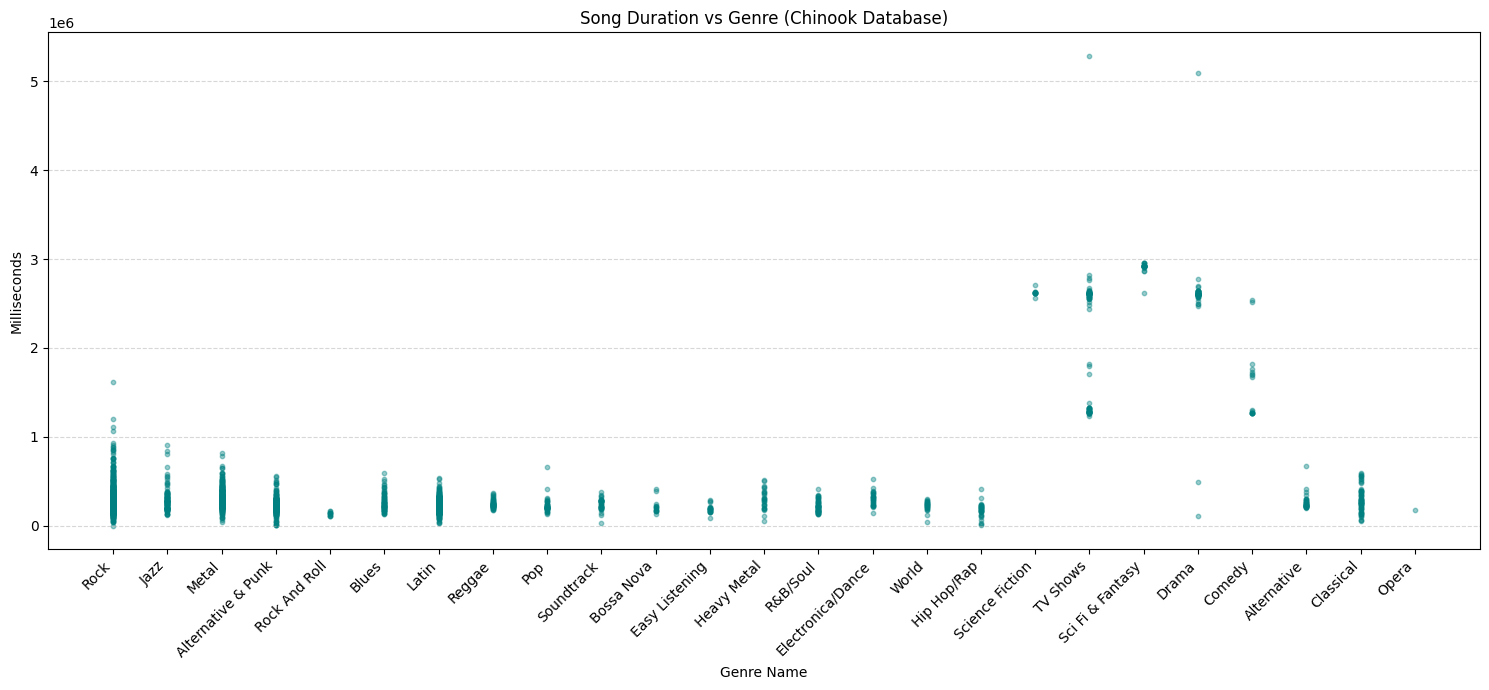

In [ ]:
# 4. Create the Plot
plt.figure(figsize=(15, 7))
plt.scatter(df['Genre'], df['Milliseconds'], alpha=0.4, color='teal', s=10)

# Formatting the visual
plt.xticks(rotation=45, ha='right')
plt.title('Song Duration vs Genre (Chinook Database)')
plt.ylabel('Milliseconds')
plt.xlabel('Genre Name')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

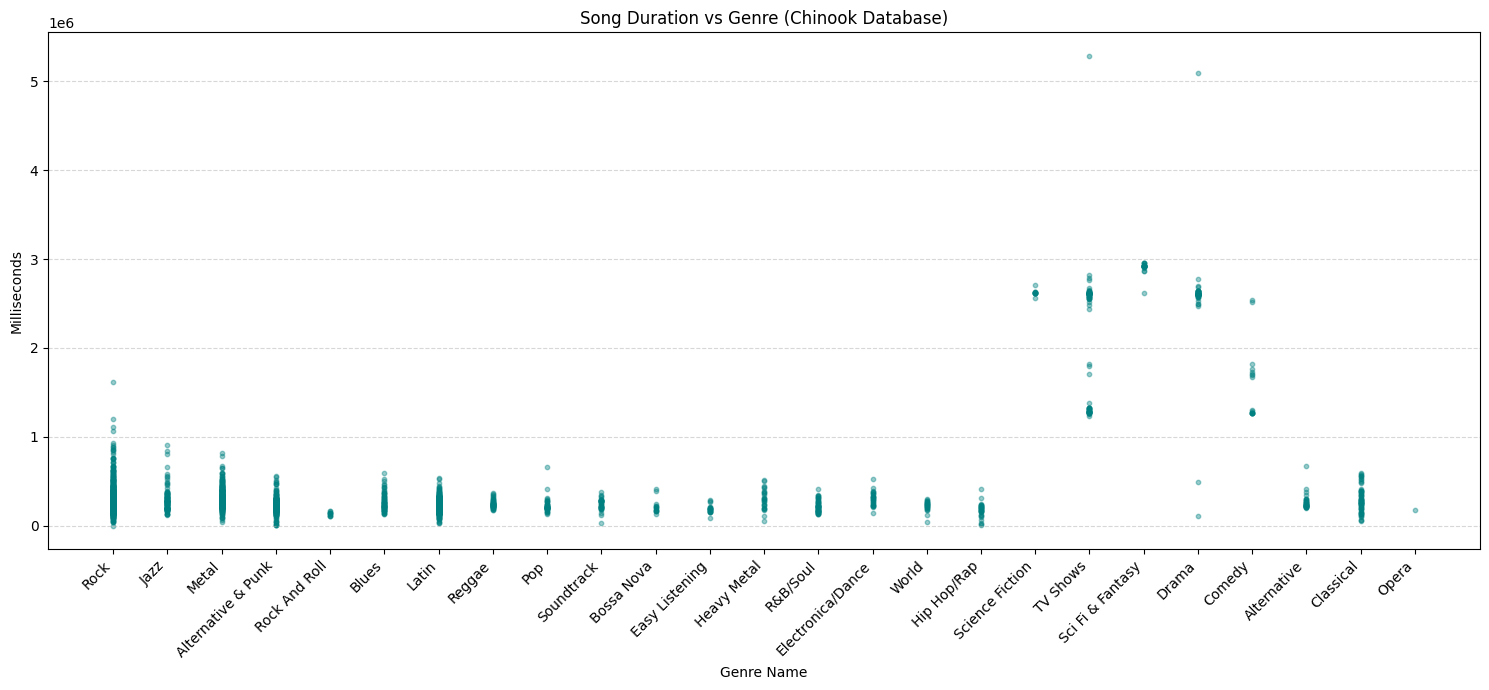

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to your database file
# Ensure chinook.db is uploaded to your Colab 'Files' section
conn = sqlite3.connect('chinook.db')

# 2. SQL Query to get the specific columns
# We'll use a JOIN to get the Genre Names instead of just IDs for a better graph
query = """
SELECT g.Name AS Genre, t.Milliseconds
FROM tracks t
JOIN genres g ON t.GenreId = g.GenreId
"""

# 3. Load into a Pandas DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

# 4. Create the Plot
plt.figure(figsize=(15, 7))
plt.scatter(df['Genre'], df['Milliseconds'], alpha=0.4, color='teal', s=10)

# Formatting the visual
plt.xticks(rotation=45, ha='right')
plt.title('Song Duration vs Genre (Chinook Database)')
plt.ylabel('Milliseconds')
plt.xlabel('Genre Name')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_16116/2813678569.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='Milliseconds', data=df, palette='Set3')


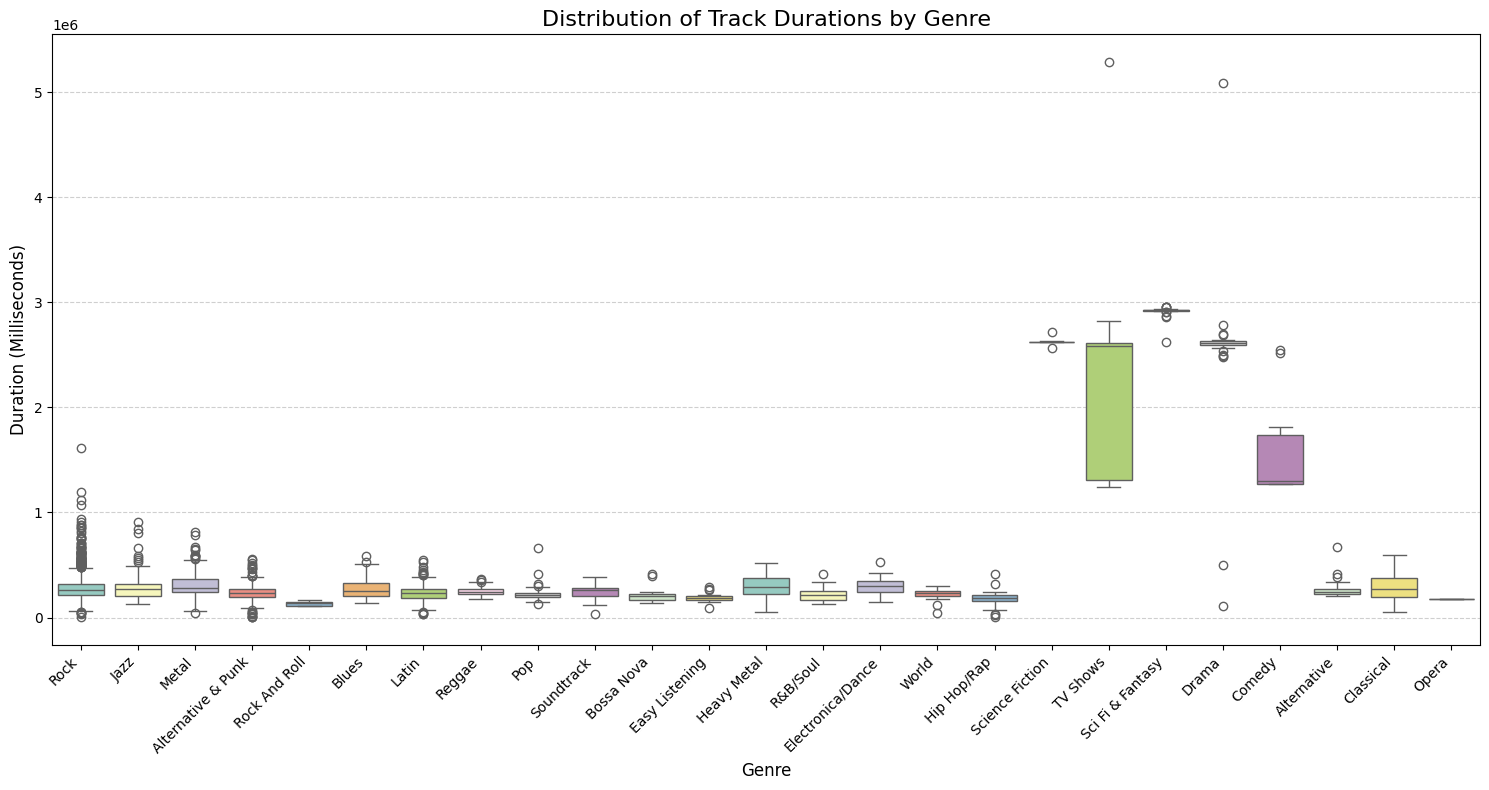

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to the database
conn = sqlite3.connect('chinook.db')

# 2. SQL Query: Joining to get Genre names makes the plot much easier to read
query = """
SELECT g.Name AS Genre, t.Milliseconds
FROM tracks t
JOIN genres g ON t.GenreId = g.GenreId
"""
df = pd.read_sql_query(query, conn)
conn.close()

# 3. Create the Box Plot
plt.figure(figsize=(15, 8))
sns.boxplot(x='Genre', y='Milliseconds', data=df, palette='Set3')

# 4. Customizing for readability
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Track Durations by Genre', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Duration (Milliseconds)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something
* Come up with something else cool to do with your data


In [ ]:
# 2. SQL Query to get the specific columns


In [ ]:
# This is an example on how to create a CTE: Common Table Expression
# From Robert's lecture 2e-sqlite3
# %%script sqlite3 --column --header
# --  A series of numbers using a CTE
# with recursive Numbers as (
#     select 0 as "Number"
#   union all
#     select Number + 1
#     from Numbers
#     where Number < 3
# )
# select *
# from Numbers n1, Numbers n2
# ;

In [ ]:
#another example from Gemini suggestions
#WITH MonthlySales AS (
#     SELECT
#         region,
#         SUM(amount) AS total_sales
#     FROM orders
#     WHERE date >= '2024-01-01'
#     GROUP BY region
# )
# SELECT * FROM MonthlySales
# WHERE total_sales > 10000;

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
# 2. SQL Query to get the specific columns: CustomerId in customers to CustomerId in invoices.
# I need the InvoiceId and the Total from invoices.
query = """
SELECT
  c.CustomerId AS Customer,
  c.Country
FROM customers c
JOIN invoices i ON c.CustomerId = i.CustomerId
"""
print(query)



SELECT
  c.CustomerId AS Customer,
  c.Country
FROM customers c
JOIN invoices i ON c.CustomerId = i.CustomerId



In [ ]:
# Connect to a sqlite database and load a result set into a data frame (context manager).  This connexion closes itself.
with db.connect('chinook.db') as conn:
  df = pd.read_sql_query(query, conn)
df


,Customer,Country
0,1,Brazil
1,1,Brazil
2,1,Brazil
3,1,Brazil
4,1,Brazil
...,...,...
407,59,India
408,59,India
409,59,India
410,59,India


In [ ]:
# to add Total on the table I created.
query = """
SELECT
    c.CustomerId AS Customer,
    c.Country,
    i.Total
FROM customers c
JOIN invoices i ON c.CustomerId = i.CustomerId
"""
print(query)


SELECT
    c.CustomerId AS Customer,
    c.Country,
    i.Total
FROM customers c
JOIN invoices i ON c.CustomerId = i.CustomerId



In [ ]:
# Connect to a sqlite database and load a result set into a data frame.  This connexion closes itself.
# context manager
with db.connect('chinook.db') as conn:
  df = pd.read_sql_query(query, conn)
df

,Customer,Country,Total
0,1,Brazil,3.98
1,1,Brazil,3.96
2,1,Brazil,5.94
3,1,Brazil,0.99
4,1,Brazil,1.98
...,...,...,...
407,59,India,5.94
408,59,India,1.99
409,59,India,1.98
410,59,India,13.86


In [ ]:
#to learn more about my df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Customer  412 non-null    int64  
 1   Country   412 non-null    object 
 2   Total     412 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 9.8+ KB


In [ ]:
#need to organize this df in descending list to know by country what is the one with most orders.
# Sort the DataFrame by 'Total' from highest to lowest
df_sorted = df.sort_values(by='Total', ascending=False)

# Display the top 10 results
print(df_sorted.head(10))

     Customer         Country  Total
41          6  Czech Republic  25.86
180        26             USA  23.86
309        45         Hungary  21.86
318        46         Ireland  21.86
171        25             USA  18.86
43          7         Austria  18.86
394        57           Chile  17.91
299        43          France  16.86
33          5  Czech Republic  16.86
162        24             USA  15.86


In [ ]:
#need to group, sum, and display in descending order.
%%script sqlite3 --column --header chinook.db

WITH CountrySpending AS (
    SELECT
        Country,
        SUM(Total) AS GrandTotal
    FROM customers c
    JOIN invoices i ON c.CustomerId = i.CustomerId
    GROUP BY Country
)
SELECT * FROM CountrySpending
ORDER BY GrandTotal DESC
limit 10;

Country         GrandTotal
--------------  ----------
USA             523.06    
Canada          303.96    
France          195.1     
Brazil          190.1     
Germany         156.48    
United Kingdom  112.86    
Czech Republic  90.24     
Portugal        77.24     
India           75.26     
Chile           46.62     


In [ ]:
#to get to genre: join InvoiceId in invoices, with invoice_items; then TrackId in invoice_items with TrackId in tracks .
%%script sqlite3 --column --header chinook.db
WITH DetailedSales AS (
    SELECT
        c.Country,
        i.InvoiceId,
        g.Name AS GenreName,
        il.UnitPrice * il.Quantity AS LineItemTotal
    FROM customers c
    JOIN invoices i ON c.CustomerId = i.CustomerId
    JOIN invoice_items il ON i.InvoiceId = il.InvoiceId
    JOIN tracks t ON il.TrackId = t.TrackId
    JOIN genres g ON t.GenreId = g.GenreId
)
SELECT * FROM DetailedSales
LIMIT 10;

Country  InvoiceId  GenreName         LineItemTotal
-------  ---------  ----------------  -------------
Brazil   98         Sci Fi & Fantasy  1.99         
Brazil   98         Sci Fi & Fantasy  1.99         
Brazil   121        Rock              0.99         
Brazil   121        Rock              0.99         
Brazil   121        Rock              0.99         
Brazil   121        Rock              0.99         
Brazil   143        Rock              0.99         
Brazil   143        Rock              0.99         
Brazil   143        Rock              0.99         
Brazil   143        Rock              0.99         


In [ ]:
#now grouping and displaying in an organized manner:
%%script sqlite3 --column --header chinook.db
WITH GenreSpending AS (
    SELECT
        c.Country,
        g.Name AS Genre,
        SUM(il.UnitPrice * il.Quantity) AS TotalSales
    FROM customers c
    JOIN invoices i ON c.CustomerId = i.CustomerId
    JOIN invoice_items il ON i.InvoiceId = il.InvoiceId
    JOIN tracks t ON il.TrackId = t.TrackId
    JOIN genres g ON t.GenreId = g.GenreId
    GROUP BY c.Country, g.Name
)
SELECT
    Genre,
    Country,
    TotalSales
FROM GenreSpending
ORDER BY TotalSales DESC
limit 10
;

Genre               Country  TotalSales      
------------------  -------  ----------------
Rock                USA      155.43          
Rock                Canada   105.93          
Latin               USA      90.0899999999999
Rock                Brazil   80.19           
Rock                France   64.35           
Metal               USA      63.36           
Rock                Germany  61.38           
Latin               Canada   59.4            
Latin               Brazil   52.47           
Alternative & Punk  USA      49.5            


In [ ]:
query = f'''
WITH GenreSpending AS (
    SELECT
        c.Country,
        g.Name AS Genre,
        SUM(il.UnitPrice * il.Quantity) AS TotalSales
    FROM customers c
    JOIN invoices i ON c.CustomerId = i.CustomerId
    JOIN invoice_items il ON i.InvoiceId = il.InvoiceId
    JOIN tracks t ON il.TrackId = t.TrackId
    JOIN genres g ON t.GenreId = g.GenreId
    GROUP BY c.Country, g.Name
)
SELECT
    Genre,
    Country,
    TotalSales
FROM GenreSpending
ORDER BY TotalSales DESC
;
'''
print(query)



WITH GenreSpending AS (
    SELECT
        c.Country,
        g.Name AS Genre,
        SUM(il.UnitPrice * il.Quantity) AS TotalSales
    FROM customers c
    JOIN invoices i ON c.CustomerId = i.CustomerId
    JOIN invoice_items il ON i.InvoiceId = il.InvoiceId
    JOIN tracks t ON il.TrackId = t.TrackId
    JOIN genres g ON t.GenreId = g.GenreId
    GROUP BY c.Country, g.Name
)
SELECT
    Genre,
    Country,
    TotalSales
FROM GenreSpending
ORDER BY TotalSales DESC
;



In [ ]:
with db.connect('chinook.db') as conn:
  df = pd.read_sql_query(query, conn)
df

,Genre,Country,TotalSales
0,Rock,USA,155.43
1,Rock,Canada,105.93
2,Latin,USA,90.09
3,Rock,Brazil,80.19
4,Rock,France,64.35
...,...,...,...
232,Electronica/Dance,Portugal,0.99
233,Hip Hop/Rap,Spain,0.99
234,Jazz,Sweden,0.99
235,World,Sweden,0.99


### Want to graph my findings

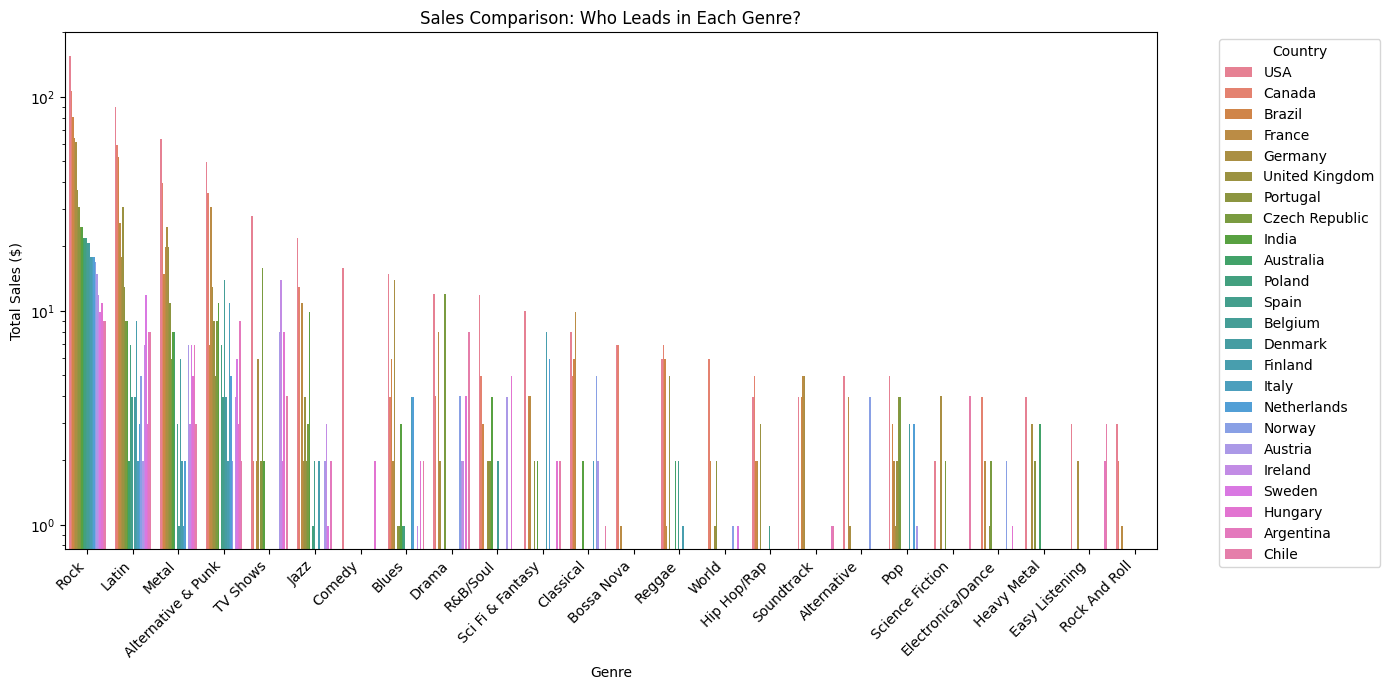

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for top genres/countries if the plot gets too crowded
top_genres =df[df['Genre'].isin(['Rock', 'Latin', 'Metal', 'Alternative & Punk'])]
top_genres =df

plt.figure(figsize=(14, 7))
sp = sns.barplot(data=top_genres, x='Genre', y='TotalSales', hue='Country')

sp.set_yscale('log')
plt.title('Sales Comparison: Who Leads in Each Genre?')
plt.ylabel('Total Sales ($)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bar.png')
plt.show()

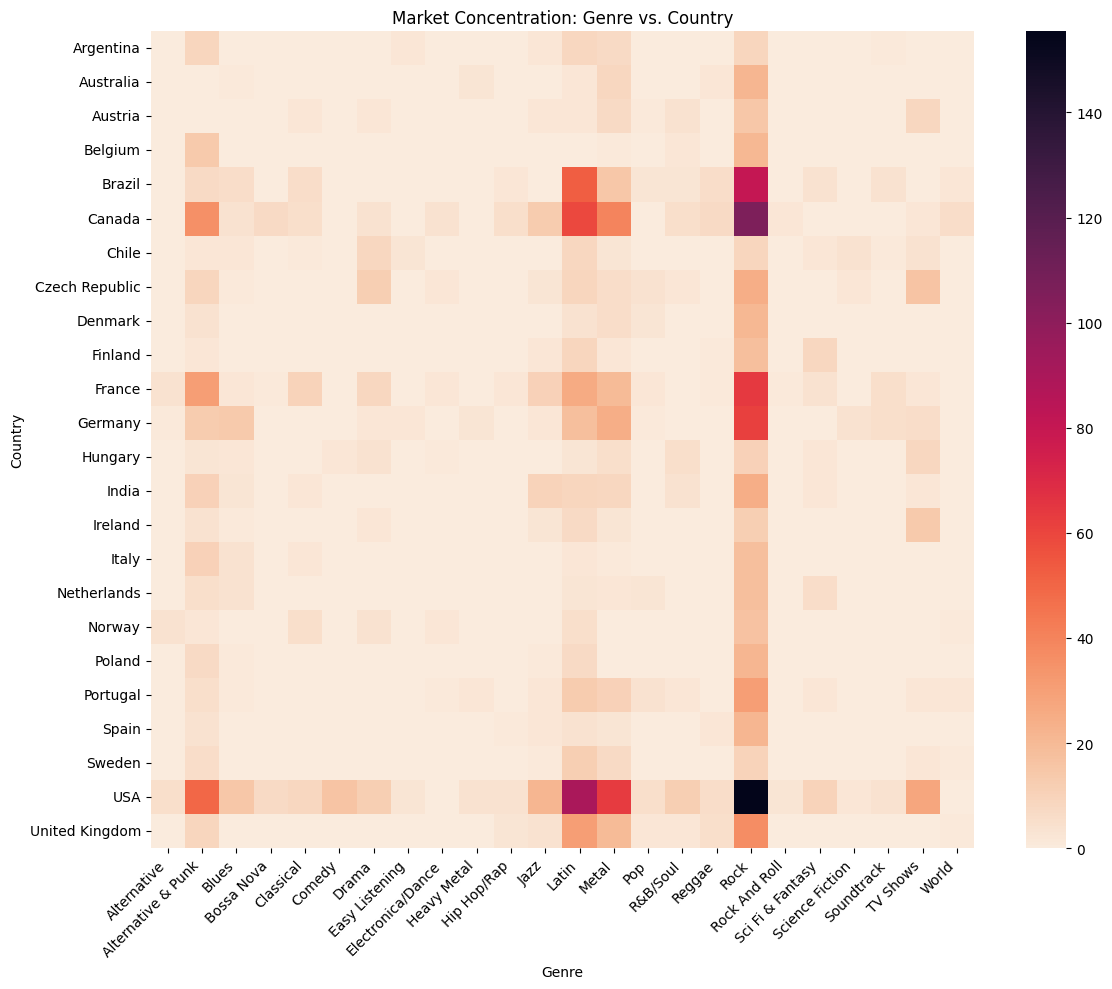

In [ ]:
# First, pivot the data: Rows = Countries, Columns = Genres

pivot_df = df.pivot(index='Country', columns='Genre', values='TotalSales').fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_df, cmap='rocket_r', annot=False) # Change annot=True to see numbers

plt.title('Market Concentration: Genre vs. Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()
